In [1]:
"""
Project: Retail & Marketing Analytics - Customer Segmentation & Sales Optimization
Notebook: 04 - Customer Segmentation and Advanced Analytics
Author: Parth Dua
Date: 06-16-2026

Objective:
- FVM matrix (frequency, volume, margin proxy)
- K-Means Clustering for customer segmentation
- Cluster profiling and characterization
- Product co-occurance category analysis
- Cohort Analysis
- Customer Lifetime Value (CLV) calculation
"""

# ============================================================================
# 1. IMPORT LIBRARIES AND LOAD DATA
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Machine Learning Core
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Market Basket / Association Mining Setup
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    MBA_AVAILABLE = True
    print("✓ mlxtend module successfully imported for Association Rules Mining")
except ImportError:
    MBA_AVAILABLE = False
    print("⚠ mlxtend not installed. Market Basket blocks will fall back to co-occurrence matrices.")
    print("  To enable association rules, execute: pip install mlxtend")

import warnings
warnings.filterwarnings('ignore')

# Set aesthetic defaults for advanced graphics
sns.set_theme(style="whitegrid")
os.makedirs('outputs/figures/segmentation', exist_ok=True)
os.makedirs('outputs/reports', exist_ok=True)

# Load cleaned dataset
df = pd.read_csv('data/processed/cleaned_retail_sales.csv')

# Parse your custom Period column back into datetimes for timeline anchoring
if 'MONTH-PERIOD' in df.columns:
    df['MONTH-PERIOD'] = pd.to_datetime(df['MONTH-PERIOD'])

print("="*80)
print("SUPPLIER SEGMENTATION AND LOGISTICAL ANALYTICS")
print("="*80)
print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

if 'SUPPLIER' in df.columns:
    print(f"Active Wholesale Providers Evaluated: {df['SUPPLIER'].nunique()}")
if 'ITEM CODE' in df.columns:
    print(f"Active Unique SKUs Analyzed:          {df['ITEM CODE'].nunique():,}")

✓ mlxtend module successfully imported for Association Rules Mining
SUPPLIER SEGMENTATION AND LOGISTICAL ANALYTICS
Dataset Shape: 29,996 rows x 27 columns
Active Wholesale Providers Evaluated: 290
Active Unique SKUs Analyzed:          15,666


In [2]:
# ============================================================================
# 2. FVM ANALYSIS (FREQUENCY, VOLUME, MIX STRATEGY)
# ============================================================================

print("\n" + "="*80)
print("FVM STRATEGIC MATRIX ANALYSIS")
print("="*80)

# Calculate FVM metrics for each active Supplier
fvm = df.groupby('SUPPLIER').agg({
    'ITEM CODE': 'count',                 # Frequency: Catalog SKU Breadth
    'TOTAL_SALES_VOLUME': 'sum',          # Volume: Total Distributed Supply Flow
    'RETAIL_CHANNEL_PCT': 'mean'          # Mix Strategy: Bias towards Storefront Retail
}).reset_index()

fvm.columns = ['SUPPLIER', 'Frequency', 'Volume', 'Mix_Strategy']

print(f"\n FVM Metrics Calculated for {len(fvm):,} unique suppliers.")
print("\nFVM Baseline Summary Statistics:")
print(fvm[['Frequency', 'Volume', 'Mix_Strategy']].describe())

# Create FVM scores (1-5 scale)
print("\n Constructing FVM Tier Scores...")

# Frequency Score (higher means wider catalog portfolio integration)
fvm['F_Score'] = pd.qcut(fvm['Frequency'].rank(method='first'), 5, 
                         labels=[1, 2, 3, 4, 5], duplicates='drop')

# Volume Score (higher means a more critical logistic heavy-lifter)
fvm['V_Score'] = pd.qcut(fvm['Volume'].rank(method='first'), 5, 
                         labels=[1, 2, 3, 4, 5], duplicates='drop')

# Mix Strategy Score (Higher means storefront-consumer focused, lower means macro-B2B warehouse focused)
fvm['M_Score'] = pd.qcut(fvm['Mix_Strategy'].rank(method='first'), 5, 
                         labels=[1, 2, 3, 4, 5], duplicates='drop')

# Combined Structural FVM Code
fvm['FVM_Code'] = (fvm['F_Score'].astype(str) + 
                    fvm['V_Score'].astype(str) + 
                    fvm['M_Score'].astype(str))

# Numeric FVM Priority Rating
fvm['FVM_Priority_Rating'] = (fvm['F_Score'].astype(int) + 
                              fvm['V_Score'].astype(int)) / 2

print("✓ FVM Strategic Scores Generated.")

# Supplier Segmentation Based on Logistic Fingerprints
def segment_suppliers(row):
    """Segment wholesale providers based on FVM footprints"""
    f, v, m = int(row['F_Score']), int(row['V_Score']), int(row['M_Score'])
    
    # Strategic Giants: High catalog breadth and high volume throughput
    if f >= 4 and v >= 4:
        if m >= 4: return 'Strategic Retail Anchor'
        if m <= 2: return 'Strategic Warehouse Anchor'
        return 'Omnichannel Giant'
        
    # High-Volume Specialist: Low diversity but moves massive item counts
    elif f <= 2 and v >= 4:
        return 'High-Velocity Focus Vendor'
        
    # Long-Tail Catalog: High SKU diversity but low structural volume
    elif f >= 4 and v <= 2:
        return 'Niche Portfolio Provider'
        
    # Mid-Tier Stable Partners
    elif 2 <= f <= 4 and 2 <= v <= 4:
        return 'Core Mainstream Vendor'
        
    # Slower/Incidental Vendors
    elif v == 1:
        return 'Low-Velocity/Boutique Supplier'
    else:
        return 'Emerging/Occasional Vendor'

fvm['Supplier_Segment'] = fvm.apply(segment_suppliers, axis=1)

print("\n Supplier Categorization Matrix Complete:")
print(fvm['Supplier_Segment'].value_counts())

# Visualize Strategic FVM Segments via Interactive Pie Chart
fig = px.pie(fvm['Supplier_Segment'].value_counts().reset_index(), 
             values='count', 
             names='Supplier_Segment',
             title='Ecosystem Distribution by Strategic FVM Supplier Segments',
             hole=0.4,
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.write_html('outputs/figures/17_fvm_segments.html')
print("✓ Saved: 17_fvm_segments.html")

# FVM Summary Profiles by Vendor Cluster Type
fvm_summary = fvm.groupby('Supplier_Segment').agg({
    'Frequency': 'mean',
    'Volume': 'mean',
    'Mix_Strategy': 'mean',
    'SUPPLIER': 'count'
}).round(2)

fvm_summary.columns = ['Avg_SKU_Breadth', 'Avg_Unit_Volume', 'Avg_Retail_Concentration_%', 'Vendor_Count']

fvm_summary['Total_Volume_Contribution_%'] = (fvm.groupby('Supplier_Segment')['Volume'].sum() / 
                                               fvm['Volume'].sum() * 100).round(2)
                                               
fvm_summary = fvm_summary.sort_values('Total_Volume_Contribution_%', ascending=False)

print("\n FVM Segment Operational Performance Metrics:")
print(fvm_summary)

# Save structured FVM analysis dataset
fvm.to_csv('data/processed/fvm_analysis.csv', index=False)
print("\n✓ Logistical FVM analysis saved to: data/processed/fvm_analysis.csv")


FVM STRATEGIC MATRIX ANALYSIS

 FVM Metrics Calculated for 290 unique suppliers.

FVM Baseline Summary Statistics:
         Frequency        Volume  Mix_Strategy
count   290.000000    290.000000    290.000000
mean    103.434483    610.619547     45.875510
std     240.087680   1404.637705     36.153596
min       1.000000      0.000000      0.000000
25%       6.250000     21.320000     12.633180
50%      20.500000     95.711875     40.066466
75%      69.250000    437.037812     84.762625
max    2070.000000  12169.750000    100.000000

 Constructing FVM Tier Scores...
✓ FVM Strategic Scores Generated.

 Supplier Categorization Matrix Complete:
Supplier_Segment
Core Mainstream Vendor            111
Low-Velocity/Boutique Supplier     58
Strategic Warehouse Anchor         46
Strategic Retail Anchor            31
Omnichannel Giant                  26
Emerging/Occasional Vendor         17
Niche Portfolio Provider            1
Name: count, dtype: int64
✓ Saved: 17_fvm_segments.html

 FVM Segme


K-MEANS CLUSTERING (SUPPLIER BEHAVIOR VECTORS)

Features selected for clustering: ['Frequency', 'Volume', 'Mix_Strategy']
Data feature matrix shape: 290 vendors x 3 descriptors
✓ Operational features standardized onto uniform scale arrays.

 Evaluating Cluster Separation Metrics across Ranges...
✓ Saved Evaluation Metric Grid: 18_optimal_clusters.png


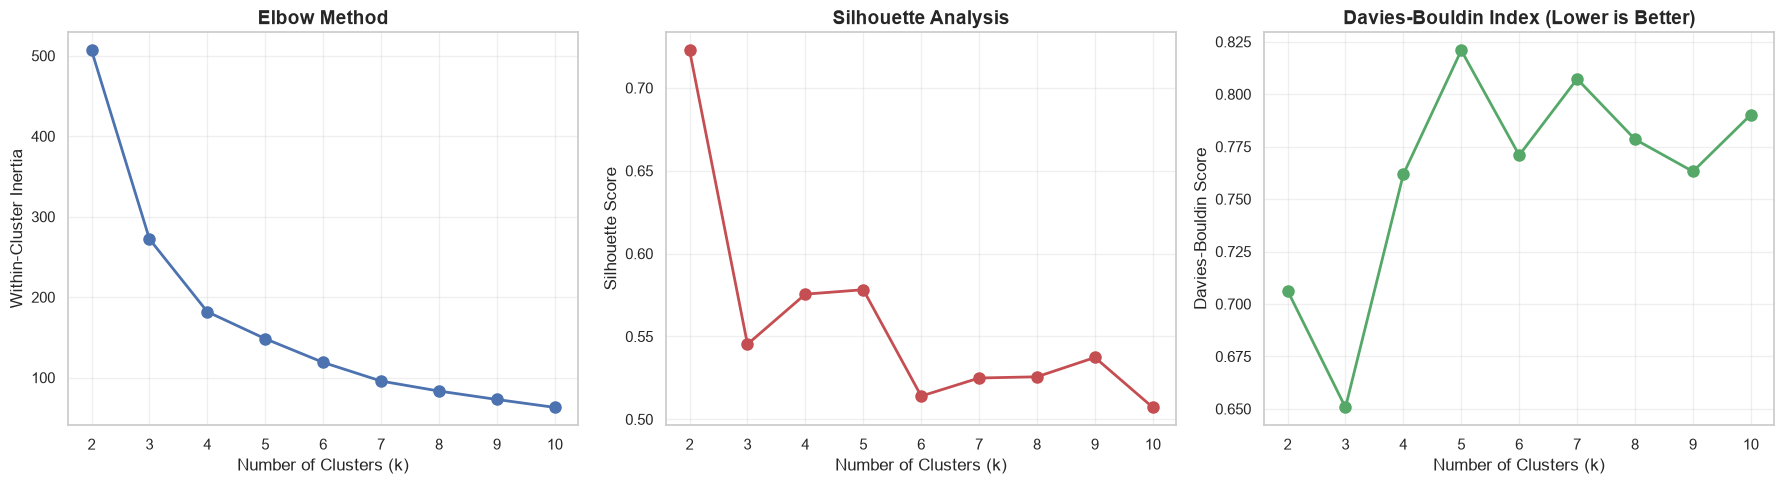


 Mathematical Clustering Evaluation Performance Breakdown:
  k=2: Inertia=506.68, Silhouette=0.7227, Davies-Bouldin=0.7064
  k=3: Inertia=272.13, Silhouette=0.5453, Davies-Bouldin=0.6507
  k=4: Inertia=181.79, Silhouette=0.5755, Davies-Bouldin=0.7619
  k=5: Inertia=148.30, Silhouette=0.5782, Davies-Bouldin=0.8209
  k=6: Inertia=118.89, Silhouette=0.5140, Davies-Bouldin=0.7709
  k=7: Inertia=95.70, Silhouette=0.5249, Davies-Bouldin=0.8073
  k=8: Inertia=83.30, Silhouette=0.5257, Davies-Bouldin=0.7785
  k=9: Inertia=72.84, Silhouette=0.5373, Davies-Bouldin=0.7632
  k=10: Inertia=62.98, Silhouette=0.5072, Davies-Bouldin=0.7902

 Recommended k selected based on peak Silhouette profile: 2

 Constructing finalized K-Means space using k=2...
✓ Pipeline execution complete!
   - Finalized Segment Silhouette Index: 0.7227
   - Finalized Segment Davies-Bouldin:  0.7064


In [3]:
# ============================================================================
# 3. K-MEANS CLUSTERING
# ============================================================================

print("\n" + "="*80)
print("K-MEANS CLUSTERING (SUPPLIER BEHAVIOR VECTORS)")
print("="*80)

# Prepare your actual logistical data features for mathematical scaling
clustering_features = ['Frequency', 'Volume', 'Mix_Strategy']
X = fvm[clustering_features].values

print(f"\nFeatures selected for clustering: {clustering_features}")
print(f"Data feature matrix shape: {X.shape[0]} vendors x {X.shape[1]} descriptors")

# Standardize features (Crucial for K-Means distance calculations)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Operational features standardized onto uniform scale arrays.")

# Determine optimal number of clusters using Elbow Method and Silhouette Score
print("\n Evaluating Cluster Separation Metrics across Ranges...")

inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

# Plot evaluation metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow Method (Inertia minimization)
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette Analysis (Cohesion vs. Separation)
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin Index (Cluster density proxy)
axes[2].plot(K_range, davies_bouldin_scores, 'go-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Score', fontsize=12)
axes[2].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/18_optimal_clusters.png', dpi=300, bbox_inches='tight')
print("✓ Saved Evaluation Metric Grid: 18_optimal_clusters.png")
plt.show()

print("\n Mathematical Clustering Evaluation Performance Breakdown:")
for k, inertia, sil_score, db_score in zip(K_range, inertias, silhouette_scores, davies_bouldin_scores):
    print(f"  k={k}: Inertia={inertia:.2f}, Silhouette={sil_score:.4f}, Davies-Bouldin={db_score:.4f}")

# Choose optimal k based directly on mathematical maximum silhouette profile
optimal_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n Recommended k selected based on peak Silhouette profile: {optimal_k}")

# Apply K-Means with optimal k configuration
print(f"\n Constructing finalized K-Means space using k={optimal_k}...")
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
fvm['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"✓ Pipeline execution complete!")
print(f"   - Finalized Segment Silhouette Index: {silhouette_score(X_scaled, fvm['Cluster']):.4f}")
print(f"   - Finalized Segment Davies-Bouldin:  {davies_bouldin_score(X_scaled, fvm['Cluster']):.4f}")

In [4]:
fvm

,SUPPLIER,Frequency,Volume,Mix_Strategy,F_Score,V_Score,M_Score,FVM_Code,FVM_Priority_Rating,Supplier_Segment,Cluster
0,A I G WINE & SPIRITS,9,26.0000,0.000000,2,2,1,221,2.0,Core Mainstream Vendor,0
1,ADAMBA IMPORTS INTL,2,7.0700,87.046632,1,1,4,114,1.0,Low-Velocity/Boutique Supplier,0
2,AIKO IMPORTERS INC,2,1.0800,50.000000,1,1,3,113,1.0,Low-Velocity/Boutique Supplier,0
3,ALLAGASH BREWING COMPANY,41,383.3625,4.763851,4,4,1,441,4.0,Strategic Warehouse Anchor,0
4,ALLIED IMPORTERS USA LTD,2,1.0000,0.000000,1,1,1,111,1.0,Low-Velocity/Boutique Supplier,0
...,...,...,...,...,...,...,...,...,...,...,...
285,WINERY EXCHANGE INC,4,22.0800,0.393701,1,2,1,121,1.5,Emerging/Occasional Vendor,0
286,YOUNG WON TRADING INC,235,968.2975,17.324160,5,5,2,552,5.0,Strategic Warehouse Anchor,0
287,YUENGLING BREWERY,51,988.8875,21.800702,4,5,2,452,4.5,Strategic Warehouse Anchor,0
288,Z WINE GALLERY IMPORTS LLC,1,0.9800,100.000000,1,1,5,115,1.0,Low-Velocity/Boutique Supplier,0


In [5]:
# ============================================================================
# 4. CLUSTER PROFILING AND CHARACTERIZATION
# ============================================================================

print("\n" + "="*80)
print("CLUSTER PROFILING AND CHARACTERIZATION")
print("="*80)

# 1. Compute Cluster descriptive statistics using your real FVM features
cluster_summary = fvm.groupby('Cluster').agg({
    'Frequency': ['mean', 'std'],
    'Volume': ['mean', 'std'],
    'Mix_Strategy': ['mean', 'std'],
    'SUPPLIER': 'count'
}).round(2)

# Flatten MultiIndex columns cleanly
cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.rename(columns={'SUPPLIER_count': 'Vendor_Count'})
cluster_summary['Vendor_Percentage'] = (cluster_summary['Vendor_Count'] / 
                                        cluster_summary['Vendor_Count'].sum() * 100).round(2)

print("\n Mathematical Cluster Summary Statistics:")
print(cluster_summary)

# 2. Dynamic Operational Naming Engine based on data vector weights
def name_clusters_by_fvm(cluster_data):
    """Assign strategic operational names to clusters based on feature dominance"""
    names = {}
    
    # Calculate dataset metrics as structural anchors
    global_avg_vol = cluster_data['Volume_mean'].mean()
    global_avg_mix = cluster_data['Mix_Strategy_mean'].mean()
    
    for cluster_id in cluster_data.index:
        f_mean = cluster_data.loc[cluster_id, 'Frequency_mean']
        v_mean = cluster_data.loc[cluster_id, 'Volume_mean']
        m_mean = cluster_data.loc[cluster_id, 'Mix_Strategy_mean']
        
        # Profile classification rules matching wholesale strategies
        if v_mean > global_avg_vol and m_mean < 35:
            names[cluster_id] = 'High-Volume Warehouse Backbones'
        elif v_mean > global_avg_vol and m_mean >= 65:
            names[cluster_id] = 'High-Volume Retail Engines'
        elif v_mean > global_avg_vol:
            names[cluster_id] = 'Omnichannel Heavyweights'
        elif f_mean > cluster_data['Frequency_mean'].median() and m_mean > global_avg_mix:
            names[cluster_id] = 'Diverse Storefront Partners'
        elif f_mean <= cluster_data['Frequency_mean'].median() and m_mean > 75:
            names[cluster_id] = 'Boutique Consumer Specialists'
        else:
            names[cluster_id] = 'Low-Velocity / Long-Tail Vendors'
            
    return names

cluster_names = name_clusters_by_fvm(cluster_summary)
fvm['Cluster_Name'] = fvm['Cluster'].map(cluster_names)

print("\n Strategic Cluster Designations:")
for cluster_id, name in cluster_names.items():
    count = cluster_summary.loc[cluster_id, 'Vendor_Count']
    pct = cluster_summary.loc[cluster_id, 'Vendor_Percentage']
    print(f"  Cluster {cluster_id}: {name} ({count:.0f} suppliers, {pct:.1f}%)")

# 3. Detailed Profile Performance Action Reports
print("\n" + "="*80)
print("DETAILED LOGISTICAL SUPPLIER PROFILES")
print("="*80)

for cluster_id, cluster_name in cluster_names.items():
    cluster_data = fvm[fvm['Cluster'] == cluster_id]
    total_vol = cluster_data['Volume'].sum()
    volume_share = (total_vol / fvm['Volume'].sum() * 100)
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id}: {cluster_name}")
    print(f"{'='*60}")
    print(f"Size: {len(cluster_data):,} suppliers ({len(cluster_data)/len(fvm)*100:.1f}%)")
    print(f"\nOperational Metrics Summary:")
    print(f"  • Avg SKU Portfolio Diversity: {cluster_data['Frequency'].mean():.1f} active codes")
    print(f"  • Avg Moving Volume per Row:   {cluster_data['Volume'].mean():,.2f} units")
    print(f"  • Avg Storefront Focus Ratio:  {cluster_data['Mix_Strategy'].mean():.2f}%")
    print(f"  • Total Dispatched Volume:     {total_vol:,.2f} units ({volume_share:.1f}% share)")
    
    print(f"\nRecommended Supply Chain Actions:")
    if 'Heavyweights' in cluster_name or 'Backbones' in cluster_name or 'Engines' in cluster_name:
        print("  ✓ Initiate tier-1 service level agreements (SLAs) to guarantee priority cross-docking.")
        print("  ✓ Setup automated API data syncs for real-time inventory tracking.")
        print("  ✓ Conduct regular joint category review meetings to prevent wholesale supply bottlenecks.")
    elif 'Diverse' in cluster_name:
        print("  ✓ Run promotional category expansions to maximize shelf space utilization.")
        print("  ✓ Incentivize portfolio expansion to capture niche regional markets.")
        print("  ✓ Review logistical transfer friction to stabilize delivery cadences.")
    elif 'Boutique' in cluster_name:
        print("  ✓ Apply selective inventory batching rules to optimize freight optimization costs.")
        print("  ✓ Position items as high-margin specialty offerings across premium consumer storefronts.")
    else: # Low Velocity
        print("  ✓ Consolidate purchase agreements to clean up vendor-management processing costs.")
        print("  ✓ Review if long-tail items can be phased out or substituted with higher-velocity lines.")

# Save modified cluster segmentation dataset to processed files
fvm.to_csv('data/processed/supplier_segments.csv', index=False)
print("\n✓ Logistical supplier segments saved to: data/processed/supplier_segments.csv")


CLUSTER PROFILING AND CHARACTERIZATION

 Mathematical Cluster Summary Statistics:
         Frequency_mean  Frequency_std  Volume_mean  Volume_std  \
Cluster                                                           
0                 63.34         108.64       365.28      624.84   
1                957.85         537.39      5838.29     2746.16   

         Mix_Strategy_mean  Mix_Strategy_std  Vendor_Count  Vendor_Percentage  
Cluster                                                                        
0                    46.38             36.67           277              95.52  
1                    35.20             20.58            13               4.48  

 Strategic Cluster Designations:
  Cluster 0: Low-Velocity / Long-Tail Vendors (277 suppliers, 95.5%)
  Cluster 1: Omnichannel Heavyweights (13 suppliers, 4.5%)

DETAILED LOGISTICAL SUPPLIER PROFILES

CLUSTER 0: Low-Velocity / Long-Tail Vendors
Size: 277 suppliers (95.5%)

Operational Metrics Summary:
  • Avg SKU Portfolio Di

In [6]:
# ============================================================================
# 5. CLUSTER VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("CLUSTER VISUALIZATION")
print("="*80)

# 5.1 PCA for 2D Dimensionality Reduction Visualization
pca = PCA(n_components=2)
# Re-using the standardized X_scaled array from Step 3 (FVM values)
X_pca = pca.fit_transform(X_scaled)

fvm['PCA1'] = X_pca[:, 0]
fvm['PCA2'] = X_pca[:, 1]

explained_var = pca.explained_variance_ratio_
print(f"\nPCA Spatial Breakdown Explained Variance:")
print(f"  • PC1: {explained_var[0]*100:.2f}%")
print(f"  • PC2: {explained_var[1]*100:.2f}%")
print(f"  • Total Explanatory Power: {sum(explained_var)*100:.2f}%")

# 2D PCA Scatter plot
fig = px.scatter(fvm, x='PCA1', y='PCA2', color='Cluster_Name',
                 title='Supplier Logistics Segments Space Visualization (PCA)',
                 labels={'PCA1': f'PC1 ({explained_var[0]:.2%} variance explained)',
                         'PCA2': f'PC2 ({explained_var[1]:.2%} variance explained)'},
                 hover_data=['Frequency', 'Volume', 'Mix_Strategy', 'SUPPLIER'],
                 color_discrete_sequence=px.colors.qualitative.Set2)
fig.write_html('outputs/figures/19_customer_segments_pca.html')
print("✓ Saved Dimensional Scatter Map: 19_customer_segments_pca.html")

# 5.2 3D Spatial Visualization in Raw FVM Vector Space
fig = px.scatter_3d(fvm, x='Frequency', y='Volume', z='Mix_Strategy',
                    color='Cluster_Name',
                    title='Wholesale Supplier Clusters inside Three-Dimensional FVM Space',
                    labels={'Frequency': 'Portfolio Frequency (SKUs)', 
                            'Volume': 'Total Supply Volume (Units)',
                            'Mix_Strategy': 'Storefront Mix %'},
                    hover_data=['SUPPLIER'],
                    color_discrete_sequence=px.colors.qualitative.Pastel)
# Adjust camera profile to better expose long-tail volume spikes
fig.update_layout(scene=dict(zaxis=dict(range=[0, 100])), height=650)
fig.write_html('outputs/figures/20_customer_segments_3d.html')
print("✓ Saved Interactive 3D Cube Mapping: 20_customer_segments_3d.html")

# 5.3 Segment Size and Supply Volume Contribution Comparison (Subplots)
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Supplier Count by Strategic Segment', 'Aggregate Transacted Volume by Segment'),
                    specs=[[{'type': 'bar'}, {'type': 'bar'}]])

segment_counts = fvm['Cluster_Name'].value_counts()
segment_volume = fvm.groupby('Cluster_Name')['Volume'].sum().sort_values(ascending=False)

# Left Side Chart: Supplier Frequency Count
fig.add_trace(go.Bar(x=segment_counts.index, y=segment_counts.values, 
                     name='Vendors', marker_color='lightblue'), row=1, col=1)

# Right Side Chart: Volume Contribution Bar
fig.add_trace(go.Bar(x=segment_volume.index, y=segment_volume.values, 
                     name='Total Unit Volume', marker_color='lightcoral'), row=1, col=2)

fig.update_xaxes(title_text="Strategic Cluster Segment", row=1, col=1, tickangle=25)
fig.update_xaxes(title_text="Strategic Cluster Segment", row=1, col=2, tickangle=25)
fig.update_yaxes(title_text="Number of Unique Suppliers", row=1, col=1)
fig.update_yaxes(title_text="Total Distributed Volume (Units)", row=1, col=2)
fig.update_layout(height=550, showlegend=False, title_text="Ecosystem Segment Distribution Analytics Dashboard")

fig.write_html('outputs/figures/21_segment_distribution.html')
print("✓ Saved Balanced Performance Dashboard: 21_segment_distribution.html")


CLUSTER VISUALIZATION

PCA Spatial Breakdown Explained Variance:
  • PC1: 61.08%
  • PC2: 32.37%
  • Total Explanatory Power: 93.45%
✓ Saved Dimensional Scatter Map: 19_customer_segments_pca.html
✓ Saved Interactive 3D Cube Mapping: 20_customer_segments_3d.html
✓ Saved Balanced Performance Dashboard: 21_segment_distribution.html


In [7]:
# ============================================================================
# 6. PRODUCT CO-OCCURRENCE / ASSOCIATION RULES ANALYSIS
# ============================================================================
# In wholesale distribution operations, this analysis uncovers cross-distribution patterns 
# revealing which item categories consistently land within the same supplier portfolios.

if MBA_AVAILABLE and 'ITEM TYPE' in df.columns and 'SUPPLIER' in df.columns:
    print("\n" + "="*80)
    print("SUPPLIER CATALOG ASSOCIATIVE ANALYSIS (MBA)")
    print("="*80)
    
    try:
        # Step 1: Aggregate item types managed together by each active supplier
        print(" Building transactional supplier baskets...")
        transactions = df.groupby('SUPPLIER')['ITEM TYPE'].apply(lambda x: list(set(x))).tolist()
        print(f"  • Total Active Operational Baskets Evaluated: {len(transactions):,}")
        
        # Step 2: One-Hot encode categories using TransactionEncoder
        te = TransactionEncoder()
        te_ary = te.fit(transactions).transform(transactions)
        df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
        
        # Step 3: Extract frequent item sets using Apriori algorithm
        print(" Mining frequent operational category sets...")
        # Adjusted min_support to account for categorical distribution profiles
        frequent_itemsets = apriori(df_encoded, min_support=0.03, use_colnames=True)
        print(f"  ✓ Extracted {len(frequent_itemsets)} valid frequent itemsets.")
        
        # Step 4: Construct and parse the association rules matrix
        print(" Computing associative lift rules...")
        rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
        rules = rules.sort_values('lift', ascending=False)
        
        print(f"  ✓ Successfully mapped {len(rules)} supplier portfolio association rules.")
        
        if len(rules) > 0:
            print("\n Top 10 Core Association Rules discovered:")
            print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).to_string())
            
            # Formulating string casts to protect Plotly rendering from set object formats
            plot_rules = rules.head(50).copy()
            plot_rules['antecedents_str'] = plot_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
            plot_rules['consequents_str'] = plot_rules['consequents'].apply(lambda x: ', '.join(list(x)))
            
            # Interactive Plotly visualizer
            fig = px.scatter(plot_rules, x='support', y='confidence', 
                             size='lift', color='lift',
                             title='Wholesale Category Associations: Support vs Confidence (Top 50 Rules)',
                             labels={'support': 'Support (Prevalence)', 'confidence': 'Confidence (Certainty)'},
                             color_continuous_scale='viridis',
                             hover_data=['antecedents_str', 'consequents_str'])
            
            fig.write_html('outputs/figures/22_association_rules.html')
            print("\n✓ Saved interactive visualization: outputs/figures/22_association_rules.html")
            
            # Store structural data report
            rules.to_csv('outputs/reports/market_basket_rules.csv', index=False)
            print("✓ Full association rule engine logs saved to: outputs/reports/market_basket_rules.csv")
        else:
            print(" ⚠ No category associations passed the required Lift/Support cutoffs. Try lowering min_support.")
            
    except Exception as e:
        print(f" ⚠ Association Mining stopped or skipped due to system error: {e}")
else:
    print("\n Associative Analysis skipped: 'mlxtend' module missing or core supply headers unavailable.")


SUPPLIER CATALOG ASSOCIATIVE ANALYSIS (MBA)
 Building transactional supplier baskets...
  • Total Active Operational Baskets Evaluated: 290
 Mining frequent operational category sets...
  ✓ Extracted 13 valid frequent itemsets.
 Computing associative lift rules...
  ✓ Successfully mapped 14 supplier portfolio association rules.

 Top 10 Core Association Rules discovered:
                  antecedents                consequents   support  confidence      lift
0           frozenset({BEER})          frozenset({KEGS})  0.151724    0.564103  3.717949
1           frozenset({KEGS})          frozenset({BEER})  0.151724    1.000000  3.717949
5   frozenset({LIQUOR, KEGS})          frozenset({BEER})  0.031034    1.000000  3.717949
6           frozenset({BEER})  frozenset({LIQUOR, KEGS})  0.031034    0.115385  3.717949
7           frozenset({KEGS})  frozenset({BEER, LIQUOR})  0.031034    0.204545  2.696281
4   frozenset({BEER, LIQUOR})          frozenset({KEGS})  0.031034    0.409091  2.696281
9 


SUPPLIER LIFECYCLE COHORT ANALYSIS

 Total Onboarding Cohorts Evaluated: 4

 Supplier Cohort Capacities (Active Base):
Cohort_Month
2020-01    268
2020-03      7
2020-07     11
2020-09      4
Freq: M, Name: SUPPLIER, dtype: int64

 Computed Supplier Cohort Retention Rates (%):
Cohort_Index      0      2      4      6      8
Cohort_Month                                   
2020-01       100.0  83.96    NaN  94.40  51.12
2020-03       100.0    NaN  57.14  14.29    NaN
2020-07       100.0  36.36    NaN    NaN    NaN
2020-09       100.0    NaN    NaN    NaN    NaN

✓ Saved clean evaluation matrix: outputs/figures/23_cohort_retention.png


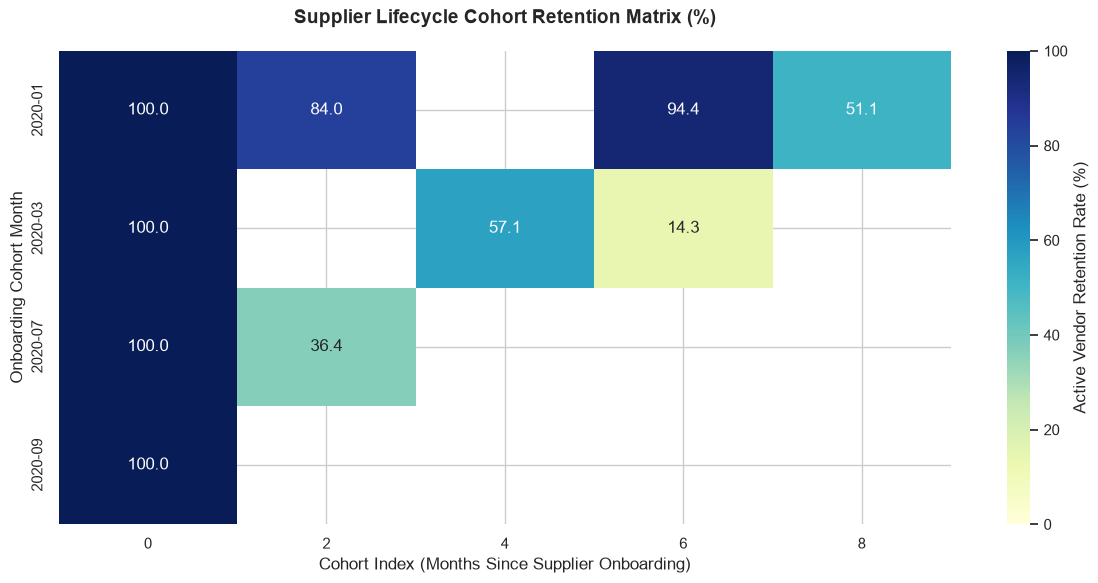

✓ Cohort retention logs saved to: outputs/reports/cohort_retention.csv


In [8]:
# ============================================================================
# 7. SUPPLIER LIFECYCLE COHORT ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("SUPPLIER LIFECYCLE COHORT ANALYSIS")
print("="*80)

# 1. Create copy and define operational activity months
df_cohort = df.copy()

# Ensure timeline is treated cleanly as native period objects for safe matrix division
df_cohort['Activity_Month'] = pd.to_datetime(df_cohort['MONTH-PERIOD']).dt.to_period('M')

# Find the onboarding cohort month for each supplier (their first logged entry)
df_cohort['Cohort_Month'] = df_cohort.groupby('SUPPLIER')['Activity_Month'].transform('min')

# 2. Calculate the Cohort Index (Number of operational months since onset)
df_cohort['Cohort_Index'] = (df_cohort['Activity_Month'] - df_cohort['Cohort_Month']).apply(lambda x: x.n)

# Compute absolute cohort size configurations (Total unique vendors onboarding in that window)
cohort_size = df_cohort.groupby('Cohort_Month')['SUPPLIER'].nunique()
print(f"\n Total Onboarding Cohorts Evaluated: {len(cohort_size)}")
print("\n Supplier Cohort Capacities (Active Base):")
print(cohort_size)

# 3. Construct the Active Retention Matrix
retention = df_cohort.groupby(['Cohort_Month', 'Cohort_Index'])['SUPPLIER'].nunique().reset_index()
retention_matrix = retention.pivot(index='Cohort_Month', columns='Cohort_Index', values='SUPPLIER')

# 4. Calculate final percentage retention rate matrix safely
retention_rate = retention_matrix.divide(cohort_size, axis=0) * 100

print("\n Computed Supplier Cohort Retention Rates (%):")
print(retention_rate.round(2))

# 5. Visualize Cohort Performance Matrix via SeaBorn Heatmap
plt.figure(figsize=(12, 6))

# Map strings onto the labels to clean up Period object text formatting bugs
heatmap_labels = [str(x) for x in retention_rate.index]

sns.heatmap(retention_rate, 
            annot=True, 
            fmt='.1f', 
            cmap='YlGnBu', 
            cbar_kws={'label': 'Active Vendor Retention Rate (%)'}, 
            vmin=0, 
            vmax=100,
            yticklabels=heatmap_labels)

plt.title('Supplier Lifecycle Cohort Retention Matrix (%)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Cohort Index (Months Since Supplier Onboarding)', fontsize=12)
plt.ylabel('Onboarding Cohort Month', fontsize=12)
plt.tight_layout()

plt.savefig('outputs/figures/23_cohort_retention.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved clean evaluation matrix: outputs/figures/23_cohort_retention.png")
plt.show()

# Save structural metrics report to disk
retention_rate.to_csv('outputs/reports/cohort_retention.csv')
print("✓ Cohort retention logs saved to: outputs/reports/cohort_retention.csv")

In [9]:
# ============================================================================
# 8. SUPPLIER LIFETIME VALUE (SLV) ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("SUPPLIER LIFETIME VALUE (SLV) CALCULATION")
print("="*80)

# Calculate SLV components using actual supply-chain parameters
supplier_metrics = df.groupby('SUPPLIER').agg({
    'TOTAL_SALES_VOLUME': ['sum', 'count'],
    'MONTH-PERIOD': ['min', 'max']
}).reset_index()

supplier_metrics.columns = ['SUPPLIER', 'Total_Volume', 'Record_Count', 'First_Active_Month', 'Last_Active_Month']

# Compute the active operational lifespan in months
supplier_metrics['Lifespan_Months'] = (
    pd.to_datetime(supplier_metrics['Last_Active_Month']).dt.to_period('M') - 
    pd.to_datetime(supplier_metrics['First_Active_Month']).dt.to_period('M')
).apply(lambda x: x.n) + 1

# Calculate Logistical Flow Metrics
supplier_metrics['Avg_Units_Per_Record'] = supplier_metrics['Total_Volume'] / supplier_metrics['Record_Count']
# Frequency represents row listings scale across active months
supplier_metrics['Supply_Frequency'] = supplier_metrics['Record_Count'] / supplier_metrics['Lifespan_Months']

# Standardized SLV Calculation 
# SLV Index = Avg Units per Entry × Entry Frequency × Projected Lifespan Anchor (4 Months Observed)
projected_lifespan_anchor = 4  
supplier_metrics['SLV_Volume_Index'] = (supplier_metrics['Avg_Units_Per_Record'] * supplier_metrics['Supply_Frequency'] * projected_lifespan_anchor)

print(f"\n SLV Index Summary Statistics:")
print(supplier_metrics['SLV_Volume_Index'].describe().round(2))

# Categorize vendors by Lifetime Volume Velocity tier (Quartile-based)
supplier_metrics['SLV_Tier'] = pd.qcut(supplier_metrics['SLV_Volume_Index'], 
                                       q=4, 
                                       labels=['Low Volume', 'Medium Volume', 'High Volume', 'Top Tier Backbone'],
                                       duplicates='drop')

print("\n Vendor Strategic Value Tier Distribution:")
print(supplier_metrics['SLV_Tier'].value_counts())

# Visualize SLV distribution using Plotly Histogram
fig = px.histogram(supplier_metrics, x='SLV_Volume_Index', 
                   title='Wholesale Supplier Lifetime Value Index Distribution',
                   nbins=50,
                   labels={'SLV_Volume_Index': 'Lifetime Volume Index (Units)'},
                   color_discrete_sequence=['steelblue'])

slv_median = supplier_metrics['SLV_Volume_Index'].median()
fig.add_vline(x=slv_median, line_dash="dash", line_color="red", 
              annotation_text=f"Median Index: {slv_median:,.2f} units")

fig.write_html('outputs/figures/24_slv_distribution.html')
print("\n✓ Saved interactive visualization: outputs/figures/24_slv_distribution.html")

# Aggregate final performance parameters per value category
slv_by_tier = supplier_metrics.groupby('SLV_Tier').agg({
    'SUPPLIER': 'count',
    'SLV_Volume_Index': 'mean',
    'Total_Volume': 'sum',
    'Record_Count': 'mean'
}).round(2)
slv_by_tier.columns = ['Supplier_Count', 'Avg_SLV_Index', 'Total_Volume_Dispatched', 'Avg_Record_Entries']

print("\n SLV Summary Profile by Strategic Tier:")
print(slv_by_tier)

# Save processed SLV datasets to data layers
supplier_metrics.to_csv('data/processed/supplier_slv.csv', index=False)
print("\n✓ SLV processing logs saved to: data/processed/supplier_slv.csv")

print("\n" + "="*80)
print("NOTEBOOK 04 COMPLETED SUCCESSFULLY!")
print("="*80)
print("\n Next Step: Open Notebook 05 - KPI Design and Dashboard Preparation")
print("="*80)


SUPPLIER LIFETIME VALUE (SLV) CALCULATION

 SLV Index Summary Statistics:
count     290.00
mean      278.09
std       622.50
min         0.00
25%        14.22
50%        53.52
75%       194.34
max      5408.78
Name: SLV_Volume_Index, dtype: float64

 Vendor Strategic Value Tier Distribution:
SLV_Tier
Low Volume           73
Top Tier Backbone    73
Medium Volume        72
High Volume          72
Name: count, dtype: int64

✓ Saved interactive visualization: outputs/figures/24_slv_distribution.html

 SLV Summary Profile by Strategic Tier:
                   Supplier_Count  Avg_SLV_Index  Total_Volume_Dispatched  \
SLV_Tier                                                                    
Low Volume                     73           5.14                   589.48   
Medium Volume                  72          32.74                  4212.63   
High Volume                    72         113.82                 15872.47   
Top Tier Backbone              73         955.07                156405.0